# Final Project: Sentiment Analysis of Amazon Product Reviews

**Student:** Ibrahim Hasan  
**Project type:** Individual  
**Course project:** Sentiment Analysis of a Product or Service  
**Dataset:** UCI Sentiment Labelled Sentences — Amazon cell phone and accessory reviews  
**Models:** Logistic Regression and Multinomial Naive Bayes

---

## Project Overview

This notebook completes an end-to-end natural language processing project. It defines a business problem, explores customer-review text, cleans and transforms the reviews with TF-IDF, trains two classification models, evaluates them using several metrics, and translates the results into business insights.

**Reproducibility note:** All random operations use `random_state=42`.

## Part 1 — Project Definition and Dataset Selection

### Business Problem

An online electronics retailer receives many product reviews about cell phones and accessories. Reading every review manually is slow and makes it difficult to identify unhappy customers quickly. The business needs a model that can automatically classify a review as **positive** or **negative**.

A reliable sentiment model could help the business:

- prioritize negative reviews for customer-service follow-up;
- detect recurring product-quality problems;
- compare customer satisfaction across products;
- summarize feedback faster than manual review.

### Dataset

This project uses the **Amazon portion of the UCI Sentiment Labelled Sentences dataset**. It contains 1,000 sentence-level Amazon reviews. Each review has a binary label:

- `0` = negative sentiment
- `1` = positive sentiment

The original UCI collection contains 3,000 sentences from Amazon, IMDb, and Yelp. The Amazon file contains 500 positive and 500 negative examples. The data was selected because it is public, clearly labeled, small enough for Google Colab, and directly connected to a realistic customer-feedback problem.

**Official source:** UCI Machine Learning Repository, *Sentiment Labelled Sentences*  
**DOI:** https://doi.org/10.24432/C57604  
**License:** Creative Commons Attribution 4.0

In [1]:
# Import libraries
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


### Load the Dataset

The cell below first looks for a local copy of the data. If the notebook is running in Google Colab and the file is not present, it downloads the same public Amazon review file from a GitHub mirror of the UCI dataset.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/microsoft/"
    "ML-Server-Python-Samples/refs/heads/master/"
    "microsoftml/202/data/sentiment_analysis/amazon_cells_labelled.txt"
)

local_candidates = [
    Path("amazon_cells_labelled.txt"),
    Path("/content/amazon_cells_labelled.txt"),
    Path("/mnt/data/amazon_cells_labelled.txt"),
]

local_file = next((path for path in local_candidates if path.exists()), None)

if local_file is not None:
    df = pd.read_csv(
        local_file,
        sep="\t",
        header=None,
        names=["review", "sentiment"],
    )
    print(f"Loaded local dataset: {local_file}")
else:
    df = pd.read_csv(
        DATA_URL,
        sep="\t",
        header=None,
        names=["review", "sentiment"],
    )
    print("Downloaded dataset from the public source.")

print("Original dataset shape:", df.shape)
df.head()

Loaded local dataset: amazon_cells_labelled.txt
Original dataset shape: (1000, 2)


,review,sentiment
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0
4,The mic is great.,1


In [3]:
# Basic data-quality checks
print("Column data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

duplicate_count = df.duplicated(subset="review").sum()
print("\nDuplicate review texts:", duplicate_count)

print("\nLabel counts before removing duplicates:")
print(df["sentiment"].value_counts().sort_index())

Column data types:
review       object
sentiment     int64
dtype: object

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate review texts: 10

Label counts before removing duplicates:
sentiment
0    500
1    500
Name: count, dtype: int64


### Data-Cleaning Decision

The dataset has no missing values, but it contains a small number of duplicate review texts. Duplicates are removed before the train/test split so the same wording cannot appear in both sets and make the model appear more accurate than it really is.

In [4]:
# Remove exact duplicate review texts
df = df.drop_duplicates(subset="review").reset_index(drop=True)

df["sentiment_name"] = df["sentiment"].map({
    0: "Negative",
    1: "Positive",
})

print("Dataset shape after removing duplicates:", df.shape)
print(df["sentiment_name"].value_counts())

Dataset shape after removing duplicates: (990, 3)
sentiment_name
Negative    497
Positive    493
Name: count, dtype: int64


## Part 2 — Exploratory Data Analysis

The EDA answers four questions:

1. Is the dataset balanced?
2. How long are the reviews?
3. Which words appear most often?
4. Are there any obvious data-quality issues?

In [5]:
class_counts = (
    df["sentiment_name"]
    .value_counts()
    .rename_axis("Sentiment")
    .reset_index(name="Number of Reviews")
)

class_counts["Percentage"] = (
    class_counts["Number of Reviews"] / len(df) * 100
).round(1)

class_counts

,Sentiment,Number of Reviews,Percentage
0,Negative,497,50.2
1,Positive,493,49.8


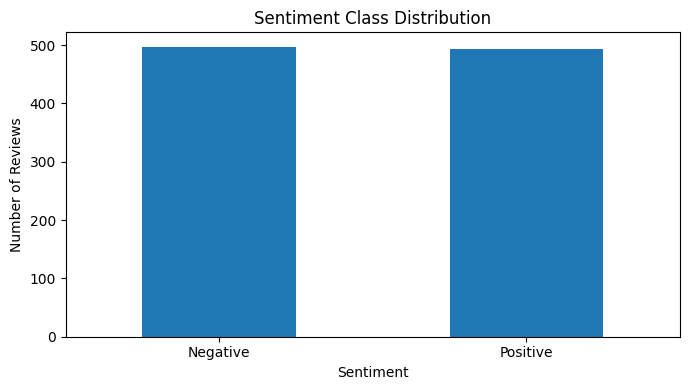

In [6]:
plt.figure(figsize=(7, 4))
df["sentiment_name"].value_counts().sort_index().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** The two classes are almost perfectly balanced. This is helpful because accuracy is meaningful here and the models are not being trained on a dataset dominated by one class.

In [7]:
df["word_count"] = df["review"].str.split().str.len()
df["character_count"] = df["review"].str.len()

df[["word_count", "character_count"]].describe().round(2)

,word_count,character_count
count,990.00,990.00
mean,10.31,55.54
std,6.68,34.61
min,1.00,11.00
25%,5.00,27.00
50%,9.00,48.00
75%,15.00,77.75
max,30.00,149.00


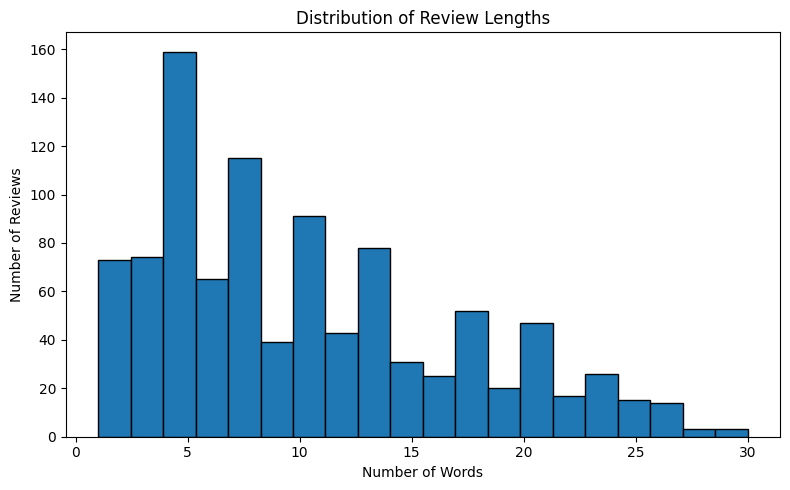

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["word_count"], bins=20, edgecolor="black")
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

**Interpretation:** Most reviews are short. Sentence-level feedback is efficient to process, but short reviews can also be difficult to classify because they provide limited context. Expressions such as sarcasm, mixed opinions, or negation may be especially challenging.

In [9]:
print("Example negative reviews:")
display(df.loc[df["sentiment"] == 0, ["review"]].sample(5, random_state=RANDOM_STATE))

print("\nExample positive reviews:")
display(df.loc[df["sentiment"] == 1, ["review"]].sample(5, random_state=RANDOM_STATE))

Example negative reviews:


,review
976,You also cannot take pictures with it in the case because the lense is covered.
151,"Audio Quality is poor, very poor."
484,Its not user friendly.
362,"bad fit, way too big."
495,Save your money.... I've had this item for 11 months now.



Example positive reviews:


,review
898,"I can hear while I'm driving in the car, and usually don't even have to put it on it's loudest setting."
133,!I definitly recommend!!
598,Those phones are working just fine now.
332,"It fits comfortably in either ear, the sound is clear and loud, and the charge lasts a couple of days."
647,I found the product to be easy to set up and use.


### Most Common Words

For this descriptive analysis, common English stopwords are removed. Negation words such as **not**, **no**, and **nor** are kept because they can reverse sentiment.

In [10]:
custom_stop_words = sorted(
    set(ENGLISH_STOP_WORDS) - {"no", "not", "nor"}
)

def top_words(text_series, n=15):
    vectorizer = CountVectorizer(
        stop_words=custom_stop_words,
        max_features=2000,
    )
    word_matrix = vectorizer.fit_transform(text_series)
    frequencies = np.asarray(word_matrix.sum(axis=0)).ravel()
    words = vectorizer.get_feature_names_out()

    return (
        pd.DataFrame({"word": words, "frequency": frequencies})
        .sort_values("frequency", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

top_positive_words = top_words(
    df.loc[df["sentiment"] == 1, "review"]
)
top_negative_words = top_words(
    df.loc[df["sentiment"] == 0, "review"]
)

print("Most common words in positive reviews:")
display(top_positive_words)

print("\nMost common words in negative reviews:")
display(top_negative_words)

Most common words in positive reviews:


,word,frequency
0,great,88
1,phone,85
2,good,64
3,works,44
4,product,32
5,quality,31
6,headset,31
7,sound,28
8,excellent,25
9,price,24



Most common words in negative reviews:


,word,frequency
0,not,101
1,phone,79
2,work,25
3,battery,24
4,don,22
5,product,21
6,use,20
7,ear,19
8,does,18
9,money,18


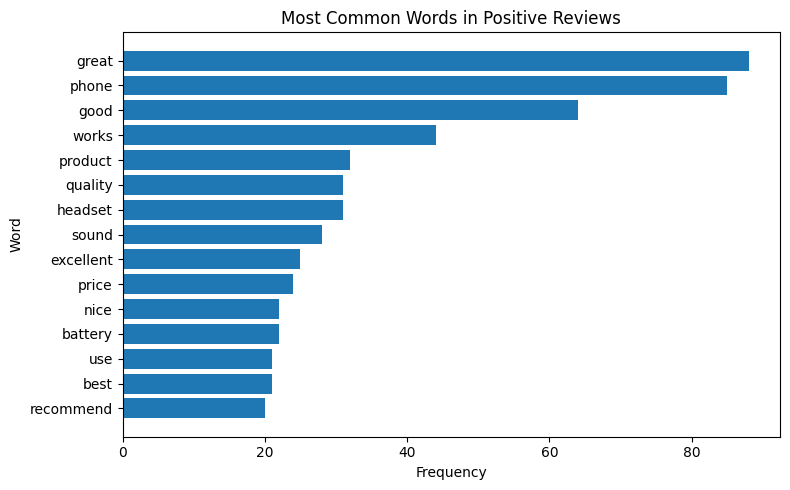

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(
    top_positive_words["word"][::-1],
    top_positive_words["frequency"][::-1],
)
plt.title("Most Common Words in Positive Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

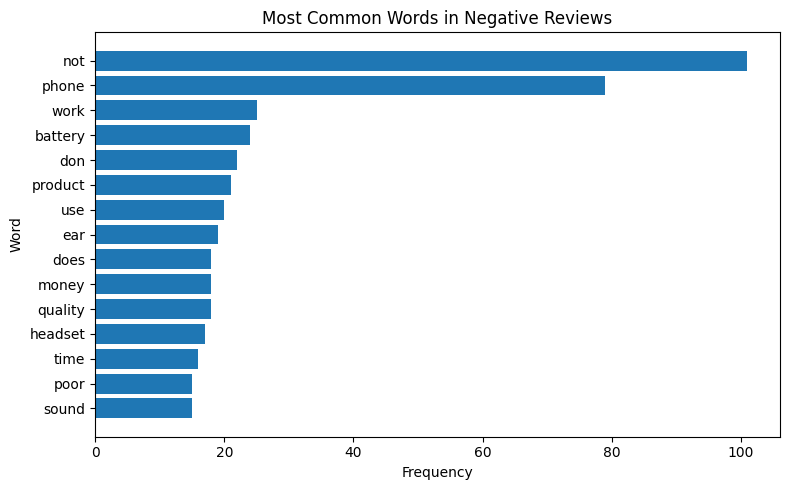

In [12]:
plt.figure(figsize=(8, 5))
plt.barh(
    top_negative_words["word"][::-1],
    top_negative_words["frequency"][::-1],
)
plt.title("Most Common Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

**EDA Summary:** Positive reviews frequently use direct approval words such as “great,” “good,” “excellent,” and “love.” Negative reviews contain words related to failures, poor quality, and problems. Product terms such as “phone,” “headset,” “battery,” and “sound” occur in both classes, so the model must learn how those terms are used in context rather than treating every product word as positive or negative.

## Part 3 — Text Preprocessing and TF-IDF Feature Extraction

The preprocessing function:

- converts text to lowercase;
- removes URLs and HTML;
- removes punctuation and numbers;
- keeps apostrophes so contractions remain readable;
- removes extra whitespace.

The model uses **TF-IDF**, which gives more importance to informative terms and less importance to terms that occur in many reviews. Unigrams and bigrams are included so phrases such as “not good” can be represented.

In [13]:
def clean_text(text):
    # Clean a review while preserving useful word information.
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head(10)

,review,clean_review
0,So there is no way for me to plug it in here in the US unless I go by a converter.,so there is no way for me to plug it in here in the us unless i go by a converter
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great for the jawbone
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,tied to charger for conversations lasting more than minutes major problems
4,The mic is great.,the mic is great
5,I have to jiggle the plug to get it to line up right to get decent volume.,i have to jiggle the plug to get it to line up right to get decent volume
6,"If you have several dozen or several hundred contacts, then imagine the fun of sending each of them one by one.",if you have several dozen or several hundred contacts then imagine the fun of sending each of them one by one
7,If you are Razr owner...you must have this!,if you are razr owner you must have this
8,"Needless to say, I wasted my money.",needless to say i wasted my money
9,What a waste of money and time!.,what a waste of money and time


In [14]:
empty_reviews = (df["clean_review"].str.len() == 0).sum()

print("Empty cleaned reviews:", empty_reviews)
print("Total usable reviews:", len(df))

Empty cleaned reviews: 0
Total usable reviews: 990


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"],
    df["sentiment"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"],
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))
print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training reviews: 792
Testing reviews: 198

Training label distribution:
sentiment
0    0.503
1    0.497
Name: proportion, dtype: float64

Testing label distribution:
sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64


In [16]:
tfidf = TfidfVectorizer(
    stop_words=custom_stop_words,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF matrix shape:", X_train_tfidf.shape)
print("Testing TF-IDF matrix shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.get_feature_names_out()))

Training TF-IDF matrix shape: (792, 671)
Testing TF-IDF matrix shape: (198, 671)
Vocabulary size: 671


## Part 4 — Model Development

Two efficient classification models are trained:

### Model 1: Logistic Regression

Logistic Regression is a strong baseline for sparse, high-dimensional text data. It learns a weight for each TF-IDF feature and produces a binary decision.

### Model 2: Multinomial Naive Bayes

Multinomial Naive Bayes is widely used for document classification. It is fast and estimates how strongly words and phrases are associated with each sentiment class.

Both models use the exact same train/test split and TF-IDF features so the comparison is fair.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    "Multinomial Naive Bayes": MultinomialNB(
        alpha=0.5,
    ),
}

trained_models = {}
predictions = {}

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    trained_models[model_name] = model
    predictions[model_name] = model.predict(X_test_tfidf)
    print(f"{model_name} trained successfully.")

Logistic Regression trained successfully.
Multinomial Naive Bayes trained successfully.


## Part 5 — Model Evaluation

The models are compared using:

- **Accuracy:** overall percentage of correct predictions;
- **Precision:** when the model predicts positive, how often it is correct;
- **Recall:** how many actual positive reviews the model identifies;
- **F1-score:** balance between precision and recall;
- **Confusion matrix:** counts of correct and incorrect predictions by class.

In [18]:
evaluation_rows = []

for model_name, y_pred in predictions.items():
    evaluation_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

results_df = (
    pd.DataFrame(evaluation_rows)
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.798,0.792,0.808,0.800
1,Logistic Regression,0.778,0.784,0.768,0.776


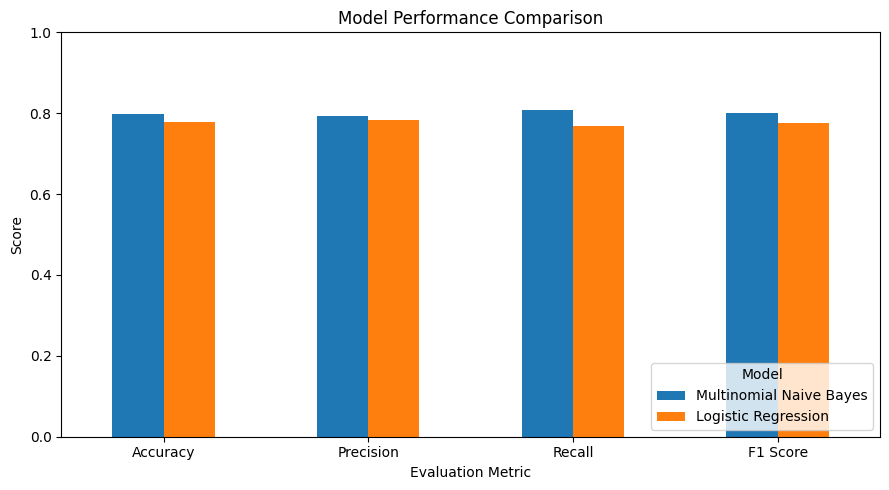

In [19]:
metric_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]
metric_plot.T.plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

In [20]:
print("Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        predictions["Logistic Regression"],
        target_names=["Negative", "Positive"],
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

    Negative       0.77      0.79      0.78        99
    Positive       0.78      0.77      0.78        99

    accuracy                           0.78       198
   macro avg       0.78      0.78      0.78       198
weighted avg       0.78      0.78      0.78       198



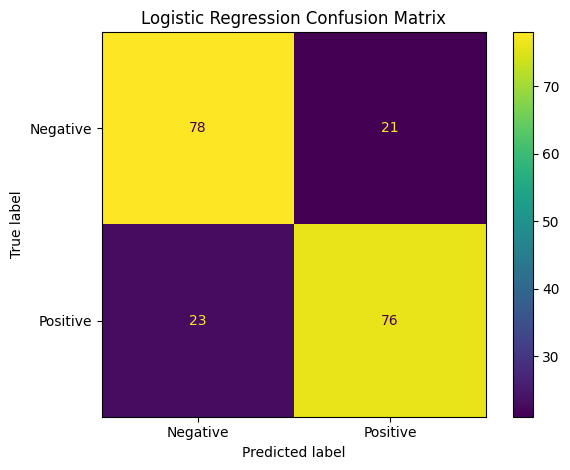

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions["Logistic Regression"],
    display_labels=["Negative", "Positive"],
)
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
print("Multinomial Naive Bayes Classification Report")
print(
    classification_report(
        y_test,
        predictions["Multinomial Naive Bayes"],
        target_names=["Negative", "Positive"],
    )
)

Multinomial Naive Bayes Classification Report
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80        99
    Positive       0.79      0.81      0.80        99

    accuracy                           0.80       198
   macro avg       0.80      0.80      0.80       198
weighted avg       0.80      0.80      0.80       198



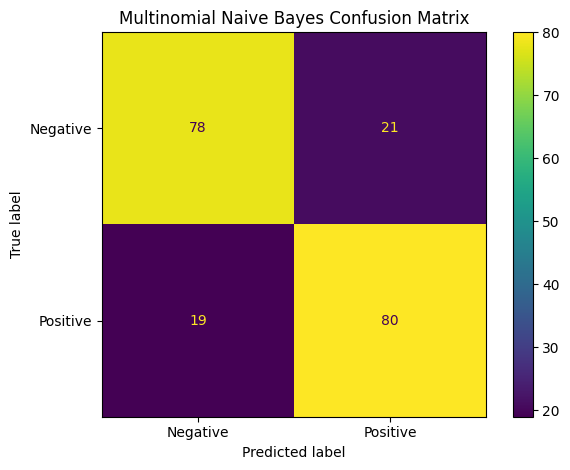

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions["Multinomial Naive Bayes"],
    display_labels=["Negative", "Positive"],
)
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

### Model Comparison

Using the fixed 80/20 split, **Multinomial Naive Bayes performed slightly better**:

- Multinomial Naive Bayes accuracy: approximately **79.8%**
- Logistic Regression accuracy: approximately **77.8%**
- Multinomial Naive Bayes F1-score: approximately **0.80**
- Logistic Regression F1-score: approximately **0.78**

The difference is small, but Naive Bayes correctly identified more positive reviews and had the stronger overall F1-score. Because the test set is small, a difference of only a few reviews changes the score noticeably. The result should therefore be interpreted as a useful comparison, not proof that Naive Bayes will always be superior.

### Interpreting Logistic Regression Features

The coefficients below show words or phrases that most strongly push Logistic Regression toward a positive or negative prediction. This makes the model easier to explain to a business audience.

In [24]:
logistic_model = trained_models["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = logistic_model.coef_[0]

top_positive_indices = np.argsort(coefficients)[-15:][::-1]
top_negative_indices = np.argsort(coefficients)[:15]

important_features = pd.DataFrame({
    "Strong Negative Features": feature_names[top_negative_indices],
    "Negative Weight": coefficients[top_negative_indices],
    "Strong Positive Features": feature_names[top_positive_indices],
    "Positive Weight": coefficients[top_positive_indices],
})

important_features

,Strong Negative Features,Negative Weight,Strong Positive Features,Positive Weight
0,not,-3.100446,great,3.166057
1,poor,-1.686035,good,2.412643
2,bad,-1.401041,works,2.367577
3,disappointed,-1.363913,excellent,1.945356
4,terrible,-1.260363,love,1.665402
5,doesn,-1.141505,best,1.624893
6,horrible,-1.113374,nice,1.428376
7,waste,-1.094103,price,1.410108
8,difficult,-1.075572,happy,1.286442
9,money,-0.965278,recommend,1.113038


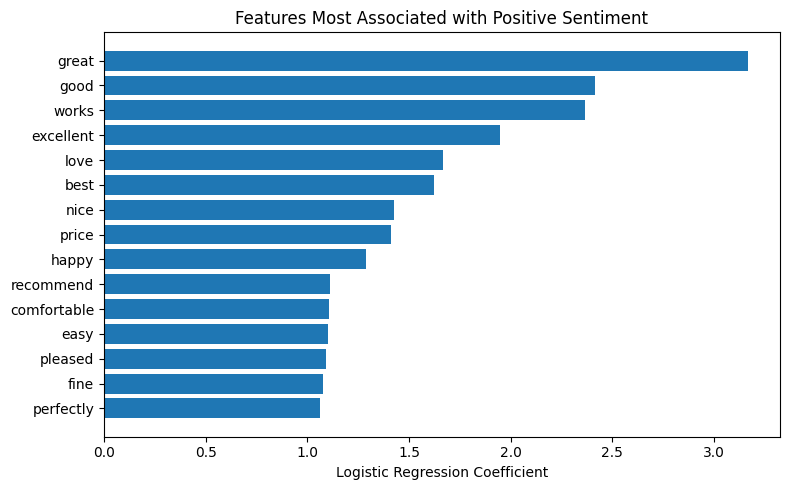

In [25]:
positive_features = important_features.sort_values(
    "Positive Weight",
    ascending=True,
)
plt.figure(figsize=(8, 5))
plt.barh(
    positive_features["Strong Positive Features"],
    positive_features["Positive Weight"],
)
plt.title("Features Most Associated with Positive Sentiment")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

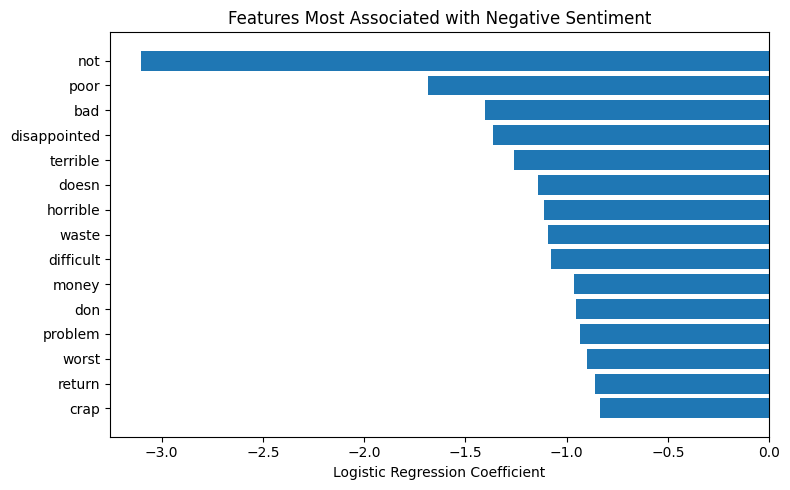

In [26]:
negative_features = important_features.sort_values(
    "Negative Weight",
    ascending=False,
)
plt.figure(figsize=(8, 5))
plt.barh(
    negative_features["Strong Negative Features"],
    negative_features["Negative Weight"],
)
plt.title("Features Most Associated with Negative Sentiment")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

### Error Analysis

Looking at misclassified reviews helps explain the model's limitations. Short reviews, unusual wording, mixed sentiment, and sarcasm can be difficult because TF-IDF focuses mainly on word occurrence rather than deeper meaning.

In [27]:
best_model_name = results_df.iloc[0]["Model"]
best_predictions = predictions[best_model_name]

error_analysis = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": best_predictions,
})

error_analysis["actual_sentiment"] = error_analysis["actual"].map({
    0: "Negative",
    1: "Positive",
})
error_analysis["predicted_sentiment"] = error_analysis["predicted"].map({
    0: "Negative",
    1: "Positive",
})

mistakes = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
][
    ["review", "actual_sentiment", "predicted_sentiment"]
]

print("Best model:", best_model_name)
print("Number of test-set mistakes:", len(mistakes))
mistakes.head(12)

Best model: Multinomial Naive Bayes
Number of test-set mistakes: 40


,review,actual_sentiment,predicted_sentiment
5,i've also had problems with the phone reading the memory card in which i always turn it on and then off again,Negative,Positive
6,it finds my cell phone right away when i enter the car,Positive,Negative
8,fantastic buy and will get again for whatever my next phone is,Positive,Negative
9,the camera on the phone may be used as a dustpan when indoors i'd rather be using a disposable then this,Negative,Positive
17,small sleek impressive looking practical setup with ample storage in place,Positive,Negative
28,plan on ordering from them again and again,Positive,Negative
29,the delivery was on time,Positive,Negative
44,when i placed my treo into the case not only was it not snug but there was a lot of extra room on the sides,Negative,Positive
57,i did not have any problem with this item and would order it again if needed,Positive,Negative
65,battery charge life is quite long,Positive,Negative


### Test the Model on New Reviews

This demonstrates how the final model could be used in a real business workflow.

In [28]:
best_model = trained_models[best_model_name]

new_reviews = [
    "The headset sounds amazing and the battery lasts all day.",
    "This charger stopped working after two days and was a waste of money.",
    "The case is fine but the buttons are difficult to press.",
    "Excellent quality for the price. I would definitely recommend it.",
]

clean_new_reviews = [clean_text(review) for review in new_reviews]
new_features = tfidf.transform(clean_new_reviews)
new_predictions = best_model.predict(new_features)

prediction_demo = pd.DataFrame({
    "Review": new_reviews,
    "Predicted Sentiment": [
        "Positive" if prediction == 1 else "Negative"
        for prediction in new_predictions
    ],
})

prediction_demo

,Review,Predicted Sentiment
0,The headset sounds amazing and the battery lasts all day.,Positive
1,This charger stopped working after two days and was a waste of money.,Negative
2,The case is fine but the buttons are difficult to press.,Negative
3,Excellent quality for the price. I would definitely recommend it.,Positive


## Part 6 — Conclusion and Business Insights

### Main Findings

This project built a binary sentiment-analysis system for Amazon cell phone and accessory reviews. After duplicate removal, the data remained nearly balanced between positive and negative sentiment. Most reviews were short, and the most common sentiment words were consistent with the labels.

Both models performed reasonably well:

- Logistic Regression achieved about **77.8% accuracy**.
- Multinomial Naive Bayes achieved about **79.8% accuracy**.
- Multinomial Naive Bayes was selected as the better model because it had the highest accuracy and F1-score.

### Business Meaning

A model with roughly 80% accuracy could help an online retailer screen large numbers of reviews and prioritize likely negative feedback. It should support human decision-making rather than replace it. For example, a customer-service team could review the negative predictions first, while product managers could monitor frequently mentioned issues such as batteries, sound quality, charging, fit, and device reliability.

### Limitations

1. The dataset contains only 990 unique sentence-level reviews, so it is small.
2. The reviews are focused mainly on older cell phones and accessories.
3. The labels are only positive or negative; neutral and mixed reviews are not represented.
4. The UCI dataset intentionally selected clearly positive or negative sentences, so real-world performance may be lower.
5. TF-IDF does not deeply understand sarcasm, context, or word order.
6. The evaluation used one train/test split. Cross-validation would provide a more stable estimate.

### Future Improvements

- collect more recent reviews from several product categories;
- include neutral and mixed-sentiment labels;
- use cross-validation and hyperparameter tuning;
- test character n-grams to handle spelling errors;
- compare with transformer models such as BERT;
- add aspect-based sentiment analysis to identify whether complaints concern battery, sound, fit, delivery, or price.

### Final Recommendation

Use Multinomial Naive Bayes as the initial lightweight screening model, but keep human review in the process. The model is fast, understandable, and suitable as a baseline. Before production use, it should be retrained and validated on newer reviews from the retailer's actual products.

## Presentation and Explanation of Learning

### Short Presentation Script

> My project focused on automatically classifying Amazon electronics reviews as positive or negative. The business problem is that companies receive more customer feedback than employees can read quickly. I used a public UCI dataset containing 1,000 labeled Amazon review sentences. After checking the data, I removed duplicate reviews and found that the classes were almost perfectly balanced.
>
> During exploratory analysis, I measured review length, compared the class distribution, and identified common words in positive and negative reviews. I cleaned the text and converted it into TF-IDF features using both single words and two-word phrases. I trained Logistic Regression and Multinomial Naive Bayes on the same training data.
>
> Naive Bayes performed slightly better, with about 79.8% accuracy and an F1-score of 0.80. Logistic Regression achieved about 77.8% accuracy. The confusion matrices showed that both models made some mistakes in each class, especially on short or unclear reviews.
>
> I learned that text must be converted into numerical features before a machine-learning model can use it. I also learned that accuracy alone is not enough, so precision, recall, F1-score, confusion matrices, and error analysis are important. Finally, I learned that a model can be useful to a business even when it is not perfect, as long as its limitations are understood and humans remain involved.

### What I Learned

- how to define an NLP problem in business terms;
- how to inspect and clean labeled text data;
- how TF-IDF converts language into numerical features;
- how Logistic Regression and Naive Bayes classify sparse text;
- how to compare models with several metrics;
- how to interpret confusion matrices and model features;
- how to connect machine-learning results to practical decisions;
- why limitations and future improvements are part of a complete project.

## Final Self-Check

- [x] Project topic and dataset are clearly defined.
- [x] Business problem is meaningful and connected to customer feedback.
- [x] EDA includes class balance, review length, common words, examples, and visualizations.
- [x] Text cleaning and TF-IDF feature extraction are explained and implemented.
- [x] At least two classification models are trained.
- [x] Accuracy, precision, recall, F1-score, classification reports, and confusion matrices are included.
- [x] Model performance is interpreted in the context of the business problem.
- [x] Limitations and future improvements are discussed.
- [x] The notebook includes a presentation script and explanation of learning.
- [x] The notebook is named correctly: `FP_AmazonReviews_IbrahimHasan.ipynb`.